In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
#Load the Data
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
df[df['TotalCharges'] == ' '].shape

(11, 21)

In [ ]:
df = df[df['TotalCharges'] != ' ']

In [ ]:
df[df['TotalCharges'] == ' '].shape

(0, 21)

In [ ]:
df['TotalCharges'].value_counts().head(10)

,count
TotalCharges,
20.2,11
19.75,9
19.65,8
19.9,8
20.05,8
45.3,7
19.55,7
19.45,6
20.25,6


In [ ]:
df.shape

(7032, 21)

In [ ]:
df['TotalCharges'].dtype

dtype('O')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].dtype


dtype('float64')

In [ ]:

df['TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
churn_rate = 1869 / (5163 + 1869) * 100
churn_rate

26.578498293515356

**Out of 7,032 customers, 26.57% have churned — meaning roughly 1 in 4 customers is leaving the telecom company, representing a significant revenue loss.**

In [ ]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887228
                Yes      0.112772
Two year        No       0.971513
                Yes      0.028487
Name: proportion, dtype: float64

**Contract type is one of the strongest drivers of churn. Month-to-month customers have a 42.7% churn rate, compared to just 11.3% for one-year contracts and only 2.8% for two-year contracts. Customers with no long-term commitment are significantly more likely to leave.**

In [ ]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


**Churned customers have an average tenure of only 18 months compared to 38 months for retained customers — meaning customers who leave tend to do so early in their relationship with the company. This suggests the first 1-2 years are the most critical period for customer retention.**

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


**Churned customers pay significantly higher monthly charges on average (₹74.4) compared to retained customers (₹61.3) — suggesting that customers who feel they are paying too much are more likely to leave. High monthly charges combined with month-to-month contracts and low tenure creates the highest churn risk profile.**

In [ ]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)

InternetService  Churn
DSL              No       0.810017
                 Yes      0.189983
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925658
                 Yes      0.074342
Name: proportion, dtype: float64

**Fiber Optic customers have the highest churn rate at 41.9%, despite being a premium service — significantly higher than DSL (19%) and customers with no internet service (7.4%). This is surprising and suggests Fiber Optic customers may feel the price doesn't justify the value, or they're experiencing service quality issues.**

In [ ]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)

PaymentMethod              Churn
Bank transfer (automatic)  No       0.832685
                           Yes      0.167315
Credit card (automatic)    No       0.847469
                           Yes      0.152531
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.807980
                           Yes      0.192020
Name: proportion, dtype: float64

**Customers paying via Electronic Check have the highest churn rate at 45.3% — almost 3x higher than automatic payment methods like Bank Transfer (16.7%) and Credit Card (15.3%). Automatic payment customers are significantly more loyal, possibly because auto-pay creates a passive commitment and reduces the friction of actively deciding to stay or leave each month.**

In [ ]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

SeniorCitizen  Churn
0              No       0.763497
               Yes      0.236503
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

**Senior citizens (coded as 1) have a significantly higher churn rate of 41.7% compared to non-senior customers at 23.6%. This suggests senior customers may find the service too expensive or complicated, and may need more targeted retention efforts like simplified plans or dedicated support**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


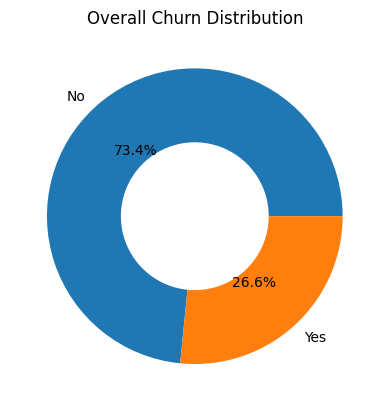

In [ ]:
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        wedgeprops={'width': 0.5})
plt.title('Overall Churn Distribution')
plt.show()

In [ ]:
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

In [ ]:
contract_churn = df.groupby('Contract')['Churn_numeric'].mean().reset_index()

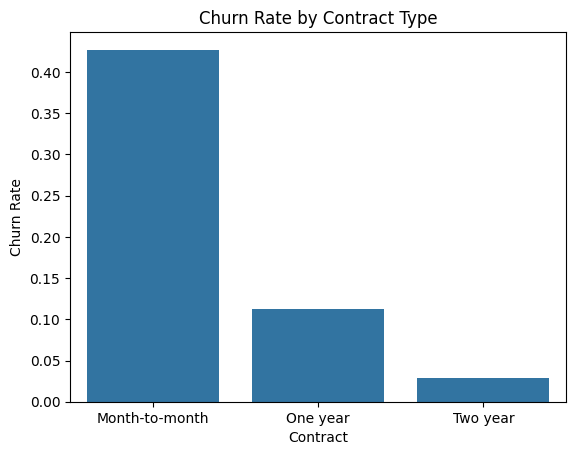

In [ ]:
sns.barplot(x='Contract', y='Churn_numeric', data=contract_churn)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

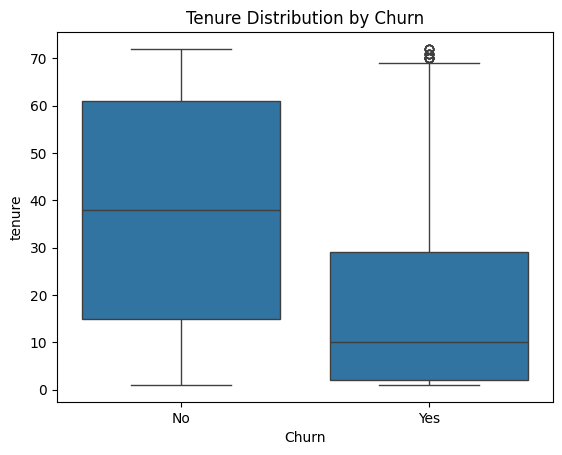

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn')
plt.show()

**Churned customers have lower tenure — confirming early months are highest risk period.**

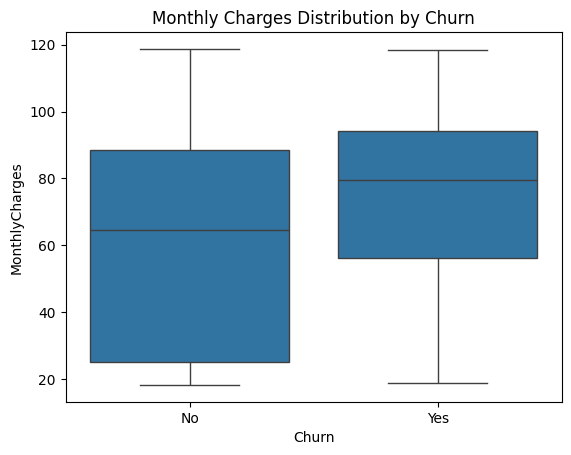

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

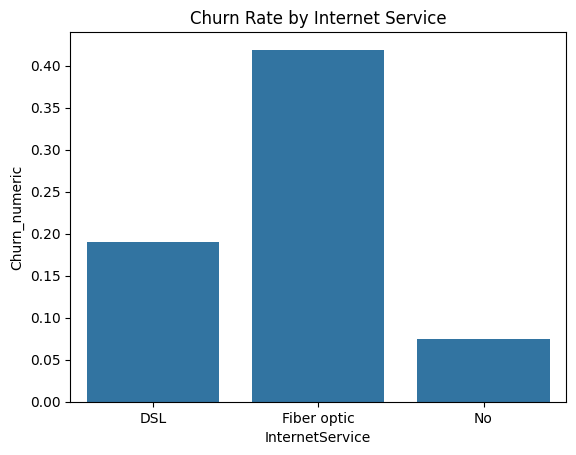

In [ ]:
InternetService_churn = df.groupby('InternetService')['Churn_numeric'].mean().reset_index()
sns.barplot(x='InternetService', y='Churn_numeric', data=InternetService_churn)
plt.title('Churn Rate by Internet Service')
plt.show()

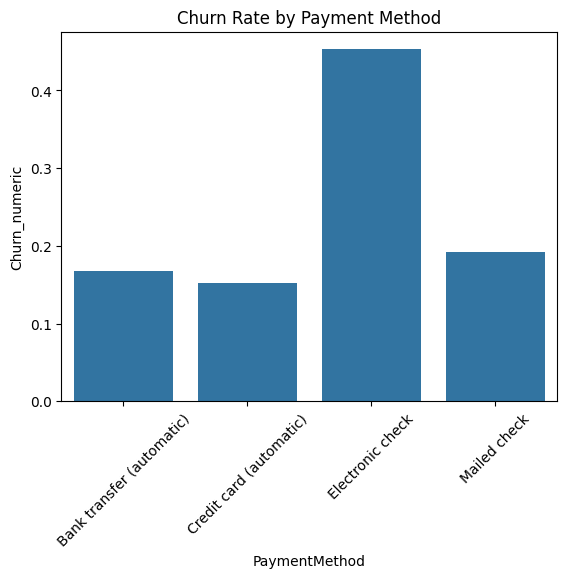

In [ ]:
PaymentMethod_churn = df.groupby('PaymentMethod')['Churn_numeric'].mean().reset_index()
sns.barplot(x='PaymentMethod', y='Churn_numeric', data=PaymentMethod_churn)
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=45)
plt.show()

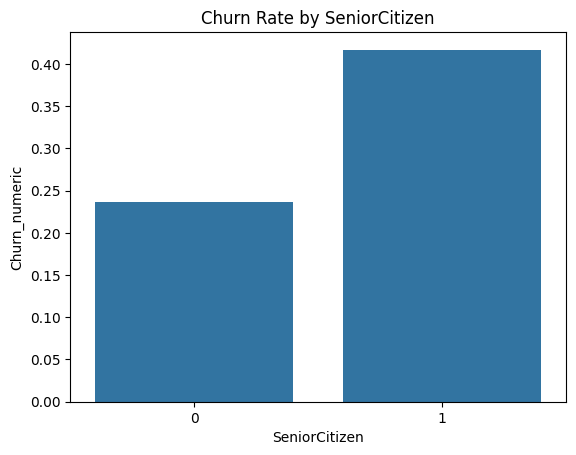

In [ ]:
SeniorCitizen_churn = df.groupby('SeniorCitizen')['Churn_numeric'].mean().reset_index()
sns.barplot(x='SeniorCitizen', y='Churn_numeric', data=SeniorCitizen_churn)
plt.title('Churn Rate by SeniorCitizen')
plt.show()

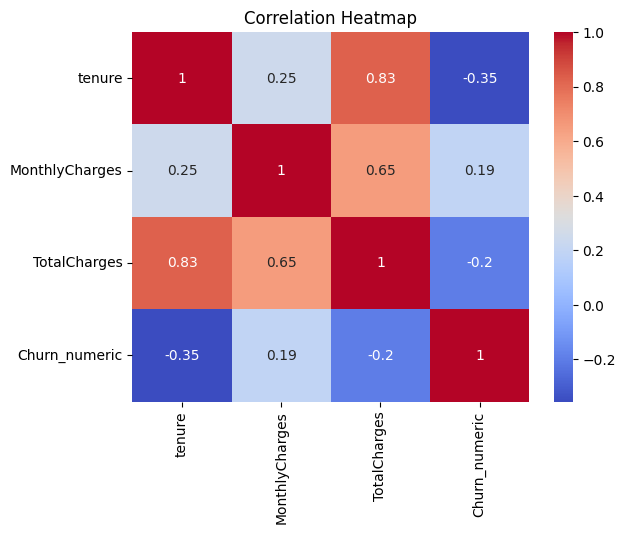

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Tenure has the strongest correlation with churn at -0.35 (negative), confirming that longer-tenured customers are less likely to churn. MonthlyCharges shows a weaker positive correlation (0.19), and TotalCharges shows -0.20 — though this is likely influenced by its strong relationship with tenure (0.83), since customers with longer tenure naturally accumulate higher total charges**

In [ ]:
import sqlite3

conn = sqlite3.connect('telco.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

7032

In [ ]:
query = """
SELECT Contract,
       AVG(Churn_numeric) as churn_rate,
       COUNT(*) as total_customers
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC
"""

result = pd.read_sql(query, conn)
result

,Contract,churn_rate,total_customers
0,Month-to-month,0.427097,3875
1,One year,0.112772,1472
2,Two year,0.028487,1685


In [ ]:
query= """SELECT InternetService, AVG(Churn_numeric) as churn_rate, COUNT(*) as total
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC"""
result=pd.read_sql(query,conn)
result

,InternetService,churn_rate,total
0,Fiber optic,0.418928,3096
1,DSL,0.189983,2416
2,No,0.074342,1520


In [ ]:
query= """SELECT Churn, AVG(tenure) as avg_tenure, AVG(MonthlyCharges) as avg_charges
FROM customers
GROUP BY Churn"""
result=pd.read_sql(query,conn)
result

,Churn,avg_tenure,avg_charges
0,No,37.650010,61.307408
1,Yes,17.979133,74.441332


In [ ]:
query="""SELECT Contract, InternetService, AVG(Churn_numeric) as churn_rate, COUNT(*) as total
FROM customers
GROUP BY Contract, InternetService
ORDER BY churn_rate DESC
LIMIT 10"""
result=pd.read_sql(query,conn)
result

,Contract,InternetService,churn_rate,total
0,Month-to-month,Fiber optic,0.546053,2128
1,Month-to-month,DSL,0.322159,1223
2,One year,Fiber optic,0.192950,539
3,Month-to-month,No,0.188931,524
4,One year,DSL,0.092982,570
5,Two year,Fiber optic,0.072261,429
6,One year,No,0.024793,363
7,Two year,DSL,0.019262,623
8,Two year,No,0.007899,633


**SQL analysis was performed using SQLite in Python, recreating key EDA findings using SQL queries. This demonstrates the ability to derive the same business insights using both Python/Pandas and SQL — a core skill for data analyst roles.**

**Data Preprocessing for ML**

In [ ]:
#Drop Columns that we don't need
df_ml = df.drop(columns=['customerID', 'Churn'])

In [ ]:
#Encode the Text Columns
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [ ]:
#Check Result
df_ml.shape

(7032, 31)

In [ ]:
#split the columns
X = df_ml.drop(columns=['Churn_numeric'])
y = df_ml['Churn_numeric']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


**Import and create the model**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

**Train the Model**

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

**Make Predictions**

In [ ]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7874911158493249

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[915 118]
 [181 193]]


**Logistic Regression model achieved 79% overall accuracy. However recall for churned customers is only 52% — meaning the model misses almost half of actual churners. For a business use case, recall is more important than precision since missing a churner (false negative) is more costly than a false alarm (false positive)**

In [ ]:
df.to_csv('telco_churn_cleaned.csv', index=False)

In [ ]:
import pickle
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)